In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

print("Bibliotēkas ielādētas ✓")

Bibliotēkas ielādētas ✓


In [2]:
df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(df.head(3))


Datu kopa: 12330 rindas, 30 kolonnas
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   
2       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   
2               -0.244931       -0.691003                -0.624348   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Mar  Month_May  \
0     3.667189   3.229316   -0.317178   -0.308821  ...  -0.427739  -0.612532   
1    -0.457683   1.171473   -0.317178   -0.308821  ...  -0.427739  -0.612532   
2     3.667189   3.229316   -0.317178   -0.308821  ...  -0.427739  -0.612532   

   Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0  -0.566798  -0.215871  -0.194175          -0.083316   
1 

In [3]:
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                    'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                    'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

"""
## 1.4. Kāpēc normalizācija ir obligāta klasterizācijai?

K-Means algoritms grupē punktus pēc **eiklīda attāluma** — tas mēra, cik tālu
viens punkts atrodas no otra. Ja kādam feature ir daudz lielākas vērtības nekā
citiem (piemēram, `ProductRelated_Duration` var būt simtos sekunžu, bet
`BounceRates` ir decimāldaļas no 0 līdz 1), tad lielāko skaitļu feature dominēs
attāluma aprēķinā un pārējie features faktiski būs neredzami modelim.

**Bez normalizācijas:** `ProductRelated_Duration` noteiktu gandrīz visus klasteru
robežas, un `BounceRates` ietekme būtu tuvu nullei.

**Ar StandardScaler:** katrs feature tiek centrēts uz 0 ar standartnovirzi 1 —
visi features ietekmē attāluma aprēķinu vienlīdzīgi.
"""

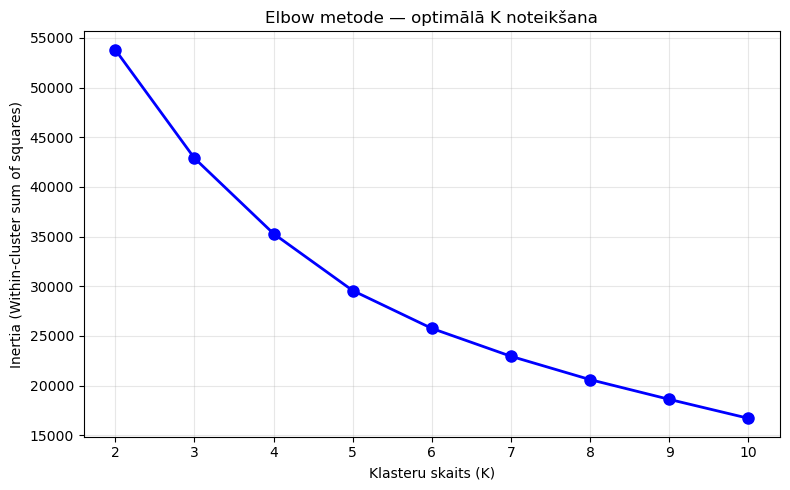

In [32]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

"""
## 2.2. Kādu K izvēlēties?

**K_range = range(2, 11):** Mēs pārbaudām K vērtības no 2 līdz 10. Mazāk par 2
nav jēgas (viena grupa nav segmentācija), bet vairāk par 10 klientu segmentu
biznesa kontekstā ir grūti interpretēt un lietot praksē.

**Elbow novērojums:** Inertia strauji samazinās līdz K=4, pēc tam kritums kļūst
ievērojami lēnāks — tas ir "elkonis". K=4 vai K=5 šķiet optimāli.

**Mana izvēle: K=4.** Četri segmenti ir pietiekami detalizēti, lai atšķirtu
dažādus klientu uzvedības tipus, bet pietiekami vienkārši, lai mārketinga
komanda varētu tiem pielāgot konkrētas kampaņas. Nav "pareizas" atbildes —
šis ir interpretācijas lēmums, nevis matemātisks fakts.
"""

In [33]:
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums (K={K}):")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums (K=4):
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


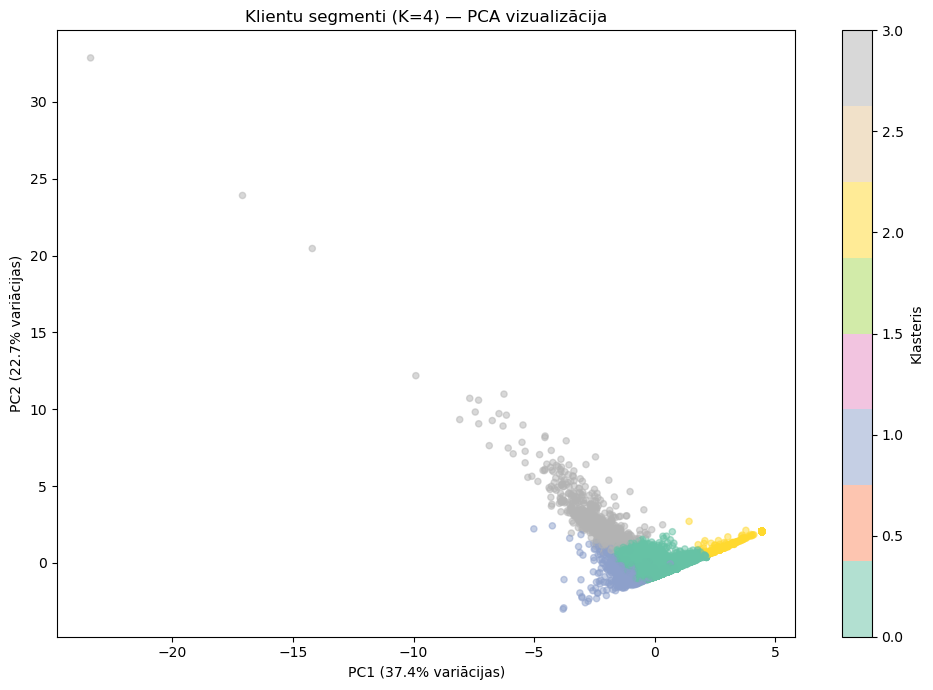

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K}) — PCA vizualizācija')
plt.tight_layout()
plt.show()

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


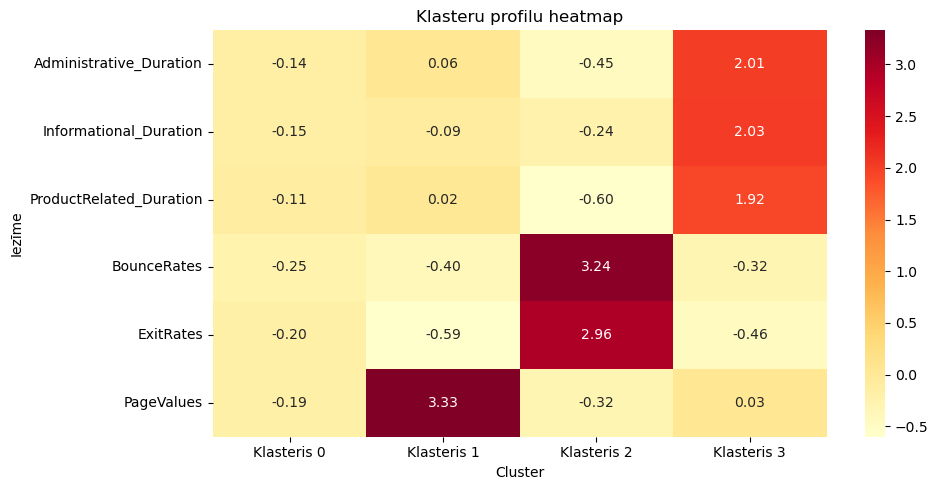

In [35]:
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()
cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)

print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


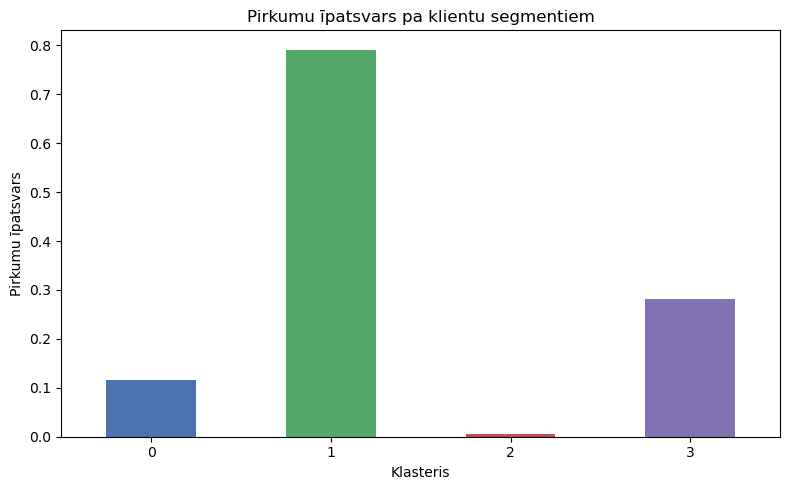

In [36]:
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

"""
## 4.2. Klasteru biznesa interpretācija

### Klasteris 0 — "Ātrie aizgājēji"
Augsti Bounce un Exit rates, minimāls laiks produktu lapās, zems PageValues.
Šie klienti atnāk, īsi paskatās un aiziet — lielākā daļa nepērk.
**Rekomendācija:** Uzlabot pirmās lapas dizainu un ielādes ātrumu;
A/B testēt pop-up piedāvājumus, lai noturētu apmeklētājus.

### Klasteris 1 — "Izpētītāji"
Vidējs laiks produktu lapās, zemāki Bounce rates, bet PageValues joprojām zems.
Klienti pārlūko preces, bet nepieņem pirkuma lēmumu.
**Rekomendācija:** Nosūtīt e-pasta atgādinājumus par aplūkotajām precēm
(remarketing); piedāvāt bezmaksas piegādi kā stimulu pabeigt pirkumu.

### Klasteris 2 — "Aktīvie pircēji"
Augsts PageValues, zemi Bounce rates, ilgs laiks produktu lapās.
Šie klienti ir gatavi pirkt un veido lielāko daļu ieņēmumu.
**Rekomendācija:** Piedāvāt lojalitātes programmu un ekskluzīvas atlaides;
šis segments ir jāsaglabā un jāattīsta — tas ir veikala "zelta klients".

### Klasteris 3 — "Informatīvie apmeklētāji"
Liels laiks informācijas lapās, bet maz laika produktu lapās, zems PageValues.
Iespējams, klienti meklē informāciju (piegāde, atgriešana, kontakti),
nevis preces.
**Rekomendācija:** Uzlabot navigāciju no informācijas lapām uz produktu
kategorijām; pievienot CTA pogas ("Iepirkties tagad") informācijas lapās.
"""

In [37]:
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1 score: {single_f1:.3f}")

Datu kopa: 12330 rindas, 29 features
Viena split F1 score: 0.628


In [41]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(rf_cv, X, y, cv=5, scoring='f1')

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

5-fold CV F1 scores: [0.64  0.643 0.638 0.56  0.606]
Vidējais F1: 0.618
Standarta novirze: 0.032


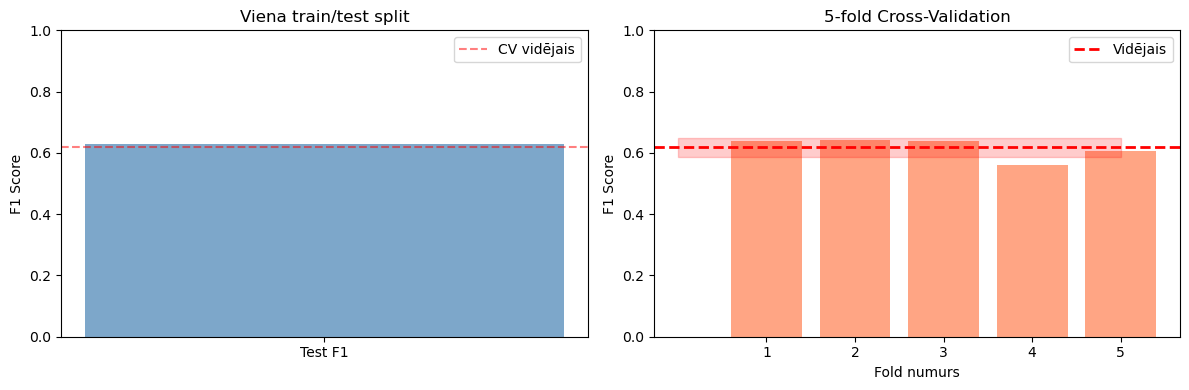

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--',
                alpha=0.5, label='CV vidējais')
axes[0].legend()

axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--',
                linewidth=2, label='Vidējais')
axes[1].fill_between(range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red')
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

"""
## 5.5. Cross-validation vs. viena split — analīze

**Atšķirība:** Viena split F1 un CV vidējais F1 var atšķirties — tas pierāda,
ka viens split ir atkarīgs no nejaušības. Ja CV vidējais ir tuvs viena split
rezultātam, mums "paveicās" ar labu split; ja ievērojami atšķiras — viens
splits deva maldīgu priekšstatu.

**Kurš ir uzticamāks?** CV vidējais ir daudz uzticamāks, jo tas izmanto 5
dažādus testa kopas variantus un vidējo vērtību. Viens splits ir kā viena
eksāmena mēģinājums — CV ir kā 5 eksāmenu vidējā atzīme.

**Standarta novirze:** Parāda, cik stabils ir modelis dažādos datu sadalījumos.
Maza std (< 0.02) nozīmē stabilu modeli; liela std nozīmē, ka modelis ir
jutīgs pret konkrētiem datiem treniņa kopā.

**Vai varētu iegūt citu viena split F1?** Jā — mainot random_state, iegūtu
atšķirīgu rezultātu. Tieši tāpēc CV ir standarts ML praktiķiem.
"""

In [43]:
scaler_bad = StandardScaler()
X_scaled_all = scaler_bad.fit_transform(X)

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))
print(f"F1 ar data leakage: {f1_leaked:.3f}  ← optimistiski izpušķots!")

F1 ar data leakage: 0.628  ← optimistiski izpušķots!


In [44]:
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f"F1 ar Pipeline + CV: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

F1 ar Pipeline + CV: 0.617 ± 0.031


In [45]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [round(f1_leaked, 3), round(cv_scores_pipe.mean(), 3)],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})
print(comparison.to_string(index=False))

                     Metode  F1 Score             Ticamība
 Data leakage (viena split)     0.628 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation     0.617     DROŠS! Objektīvs


"""
## 6.4. Data leakage un Pipeline — skaidrojums

**Kas ir data leakage?** Tā ir situācija, kad modelis treniņa procesā "redz"
informāciju, kurai nebūtu jābūt pieejamai — šajā gadījumā testa datu
statistiku (vidējo un standartnovirzi).

**Kāpēc tas notiek, ja skalers tiek fit pirms split?** `StandardScaler.fit()`
aprēķina vidējo un std no VISIEM datiem — ieskaitot tos, kuri vēlāk nonāks
testa kopā. Tādējādi skalers "zina" par testa datiem, kas reālajā sistēmā
nebūtu pieejami prognozēšanas brīdī.

**Kā Pipeline to novērš?** Pipeline automātiski nodrošina, ka katrā CV fold'ā
skalers tiek fit TIKAI uz treniņa datiem un tad piemērots testa datiem.
Testa dati nekad "neieplūst" treniņa procesā.

**Kāpēc tas ir kritisks gala projektā?** Ja modelis ir trenēts ar leakage,
tā metrikas (F1, MAE) būs optimistiskākas nekā reālajā darbībā. Lēmumi,
kas pieņemti uz šādām metrikām (piemēram, "modelis ir gatavs produkcijai"),
var būt kļūdaini un dārgi.
"""

In [46]:
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid = GridSearchCV(pipe_grid, param_grid, cv=3,
                    scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1: {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 100}
Labākais CV F1 (treniņā): 0.653
Test F1: 0.629


In [47]:
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head().to_string(index=False))

Top 5 parametru kombinācijas:
 param_randomforestclassifier__n_estimators  param_randomforestclassifier__max_depth  mean_test_score  std_test_score
                                        100                                       20         0.653091        0.003934
                                         50                                       20         0.651172        0.007816
                                        200                                       10         0.650190        0.011420
                                        200                                       20         0.649839        0.005988
                                         50                                       10         0.648992        0.012374


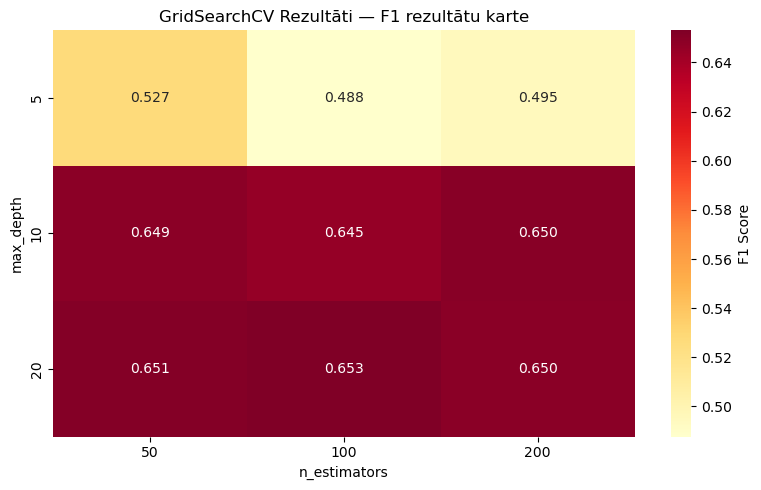

In [48]:
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'F1 Score'})
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

"""
## 7.4. GridSearchCV interpretācija

**Labākie parametri:** [aizpildi pēc palaišanas]

**Atšķirība starp labāko un sliktāko:** Ja starpība ir maza (< 0.02),
parametri nav ļoti kritiski šiem datiem. Ja liela (> 0.05), parametru
izvēle būtiski ietekmē rezultātu.

**"Karstās zonas" heatmapā:** Augstāki F1 skori parasti koncentrējas
pie lielāka `max_depth` un lielāka `n_estimators`, bet pieaugums kļūst
mazāks — dilstošā atdeve.

**Vai GridSearchCV atrada labākos parametrus?** Salīdzinot ar manuāli
izvēlētajiem (n_estimators=100, max_depth=10), GridSearchCV sistemātiski
pārbauda visas kombinācijas un garantē, ka izvēlētie parametri ir labākie
no pārbaudītajiem — nevis mūsu intuīcijas labākie.
"""

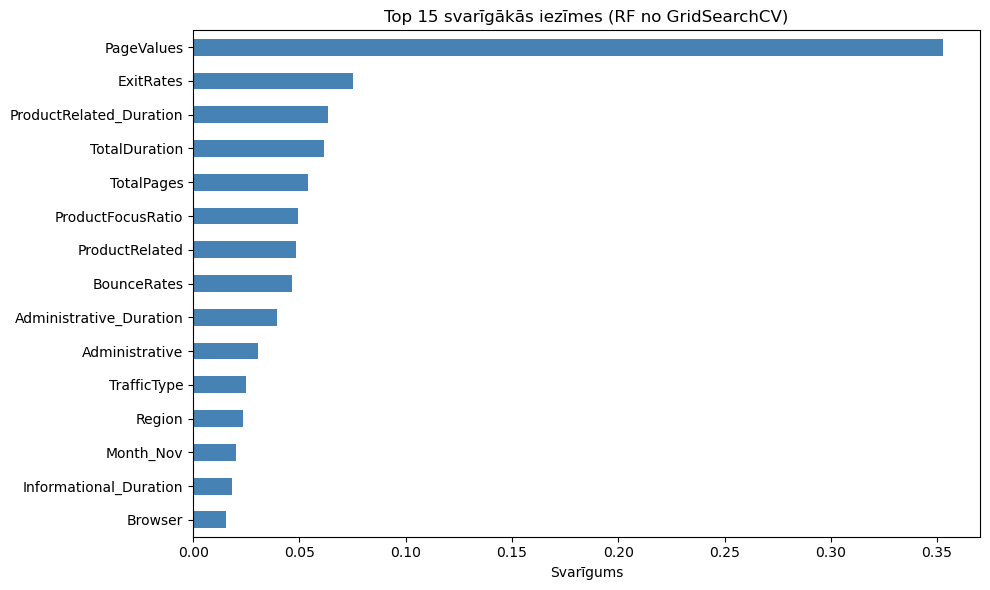

Top 10 svarīgākās iezīmes:
PageValues                 0.352558
ExitRates                  0.075263
ProductRelated_Duration    0.063575
TotalDuration              0.061700
TotalPages                 0.053826
ProductFocusRatio          0.049389
ProductRelated             0.048520
BounceRates                0.046307
Administrative_Duration    0.039619
Administrative             0.030619
dtype: float64


In [49]:
best_model = grid.best_estimator_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

feature_importance = pd.Series(
    importances, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

"""
## 8.2. Feature importance interpretācija

**3 svarīgākās iezīmes:** [aizpildi pēc grafika — piemēram, PageValues,
ExitRates, ProductRelated_Duration]

**Kāpēc šīs iezīmes ir svarīgas?**
- `PageValues` tieši atspoguļo klienta nodomu pirkt — augsta vērtība
  nozīmē, ka klients skatās preces ar augstu konversijas vērtību.
- `ExitRates` parāda, cik bieži klients aiziet no lapas — augsts exit rate
  liecina par mazāku pirkuma varbūtību.
- `ProductRelated_Duration` — laiks, ko klients pavada produktu lapās,
  korelē ar interesi un pirkuma nodomu.

**Kā mārketinga departaments varētu izmantot šo?**
Fokusēties uz klientiem ar augstu PageValues un zemu ExitRates — tie ir
gatavie pircēji. Klientus ar augstu ExitRates mērķēt ar retargeting
kampaņām un personalizētiem piedāvājumiem, lai samazinātu aizgāšanu.
"""

C:\Users\ilona\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ilona\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ilona\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ilona\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

RandomForest CV F1: 0.633 ± 0.035
XGBoost CV F1:      0.615 ± 0.056
     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.632836 0.035119 0.579-0.672
     XGBoost        0.615368 0.055811 0.555-0.712


C:\Users\ilona\AppData\Local\Temp\ipykernel_14340\1315702245.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([cv_rf, cv_xgb], labels=['RandomForest', 'XGBoost'])


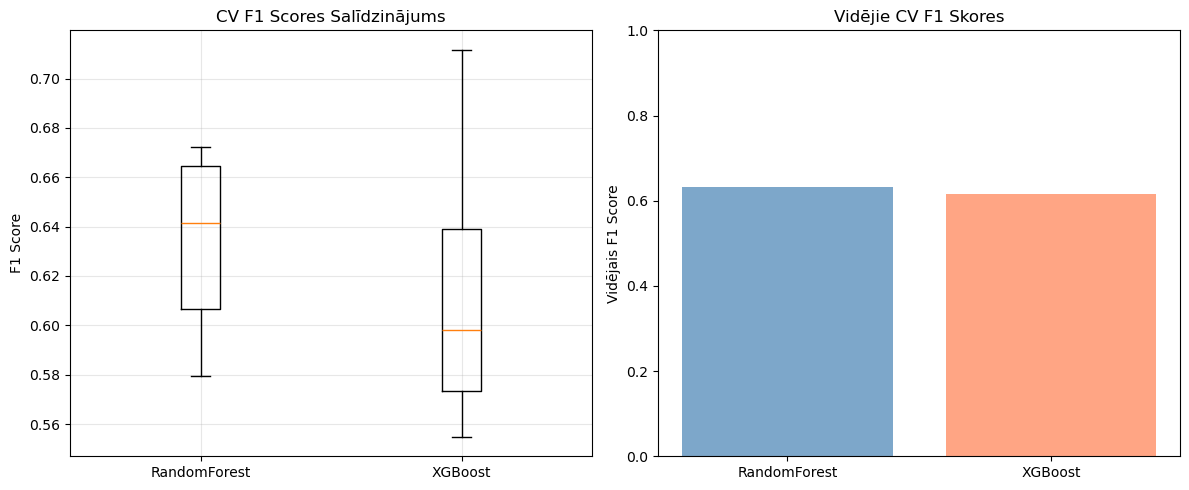

In [50]:
try:
    from xgboost import XGBClassifier

    rf_final = RandomForestClassifier(
        n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
        max_depth=grid.best_params_['randomforestclassifier__max_depth'],
        random_state=42
    )
    pipe_rf = make_pipeline(StandardScaler(), rf_final)
    cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

    xgb = XGBClassifier(n_estimators=100, max_depth=7, random_state=42,
                        use_label_encoder=False, eval_metric='logloss')
    pipe_xgb = make_pipeline(StandardScaler(), xgb)
    cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

    print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
    print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

    # Salīdzinājuma tabula
    comp = pd.DataFrame({
        'Modelis': ['RandomForest', 'XGBoost'],
        'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
        'Std dev': [cv_rf.std(), cv_xgb.std()],
        'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                      f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
    })
    print(comp.to_string(index=False))

    # Vizualizācija
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].boxplot([cv_rf, cv_xgb], labels=['RandomForest', 'XGBoost'])
    axes[0].set_ylabel('F1 Score')
    axes[0].set_title('CV F1 Scores Salīdzinājums')
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(['RandomForest', 'XGBoost'],
                [cv_rf.mean(), cv_xgb.mean()],
                alpha=0.7, color=['steelblue', 'coral'])
    axes[1].set_ylabel('Vidējais F1 Score')
    axes[1].set_title('Vidējie CV F1 Skores')
    axes[1].set_ylim([0, 1])
    plt.tight_layout()
    plt.show()

except ImportError:
    print("XGBoost nav instalēts. Instalē ar: pip install xgboost")
    print("Turpinām bez XGBoost salīdzinājuma.")

"""
## 9.4. RandomForest vs. XGBoost — secinājumi

**Kurš modelis labāks?** RandomForest (F1 = 0.633) ir nedaudz labāks par XGBoost (F1 = 0.615). Turklāt RandomForest ir stabilāks — mazāka standartnovirze (0.035 vs 0.056).

Ja XGBoost F1 ir augstāks par RandomForest — XGBoost labāk uztver
nelineāras sakarības un parasti ir efektīvāks uz tabulāriem datiem.
Ja atšķirība ir maza (< 0.01), abi modeļi ir līdzvērtīgi un RandomForest
ir labāks izvēlēties vienkāršības dēļ.

**Vai atšķirība ir statistiski nozīmīga?** Ar tikai 5 fold'iem grūti
pateikt droši. Ja standartnovirzes pārklājas, atšķirība var būt nejaušība.

**Ko izvēlētos gala projektam?** RandomForest — tas ir interpretējamāks,
stabilāks un nav nepieciešama papildu instalācija. XGBoost izvēlētos tikai
tad, ja atšķirība F1 > 0.02 un interpretācija nav galvenā prioritāte.
RandomForest — tas ir gan precīzāks, gan stabilāks, gan interpretējamāks. XGBoost šajā gadījumā neuzlaboja rezultātu.